# 兩階段訓練 — SimpleCNN + 困難負樣本挖掘

**Stage 1**：二分類（none / non-none）。閾值調到 `S1_THRESHOLD = 0.1`，寧可把 none 誤判成有缺陷，
也不要漏掉 Edge-Loc / Loc / Scratch。

**Stage 2**：**9 類**分類（8 種缺陷 + none）。訓練資料除了 8 類缺陷，還加進「Stage 1 誤判成有缺陷的
none 樣本」，讓它有機會把 Stage 1 的假警報修正回 none。

**最終分數**：兩階段真的串起來跑一次 test，用串接後的輸出對真實 9 類標籤算分，
不是把兩關分數各算各的再平均。

## 資料切分（先切好，之後不再重切）

```
df_all（有標籤資料，依 9 類 failureType 分層切 70 / 15 / 15）
├── split = train
│   ├── 8 類缺陷 ─────────────────► S1 訓練（label=1）＋ S2 訓練（9 類，含增強）
│   └── none 對半切成數量一樣的兩塊
│       ├── A ───────────────────► S1 訓練（label=0）
│       └── B（S1 完全不看）
│           └── S1 訓練完拿 S1 篩一次
│               ├── 被誤判成有缺陷 ──► S2 訓練集的 none
│               └── 判對的 ─────────► 之後不再使用
├── split = val
│   ├── 8 類缺陷 ─────────────────► S1 驗證（label=1）＋ S2 驗證（8 類）
│   └── none ────────────────────► S1 驗證（label=0），S1 訓練完再篩一次
│       ├── 被誤判成有缺陷 ───────► S2 驗證集的 none
│       └── 判對的 ──────────────► 之後不再使用
└── split = test ────────────────► 全程不碰，最後端到端只跑這一次
```

為什麼兩批 none 都要先過 Stage 1 篩一次：
1. 部署時只有「被 Stage 1 判成有缺陷」的樣本會進 Stage 2，所以 S2 的訓練集和驗證集的 none
   都改用這種樣本，分布才和實際會遇到的一致。
2. 訓練用的困難 none 來自 B、驗證用的來自 val，兩批天生不重疊，S2 不會拿訓練過的樣本當驗證。
3. B 從頭到尾沒進過 Stage 1 的訓練集，篩出來的困難樣本不是「模型背過的那些」。

Cell 執行順序：
- **Cell 1**：環境設定（只需執行一次）
- **Cell 2**：實驗設定（換參數只改這裡，改完重跑 Cell 4+）
- **Cell 3**：載入資料（只需執行一次，換設定不需重跑）
- **Cell 4**：全域切分 train / val / test，並把 train 的 none 對半切成 A / B
- **Cell 5–7**：Stage 1 準備 / 訓練 / 驗證結果
- **Cell 8**：困難樣本挖掘（B 篩一次、val 的 none 篩一次）
- **Cell 9–11**：Stage 2 準備 / 訓練 / 驗證結果
- **Cell 12**：端到端測試（唯一一次動 test）
- **Cell 13**：單筆推論時間
- **Cell 14**：儲存結果

In [22]:
import sys
sys.path.insert(0, '..')
# Cell 1 — 環境設定（只需執行一次）
%matplotlib inline
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tabulate import tabulate
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

from constant import LABEL_MAP, NONE_NONONE_LABEL_MAP
from data.dataset import (
    WaferSimpleDataset,
    augment_selected_classes,
    extract_labeled_patterned_data,
    load_raw_data,
    make_dataloaders,
    split_df,
)
from engine.trainer import print_metrics, print_per_class_f1, run_one_epoch, train_model
from engine.visualize import plot_cm, plot_history
from models.simple_cnn import SimpleCNN
from utils import EpochTimer, make_output_dir, save_results, set_seed

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"使用裝置：{device}")

使用裝置：cpu


In [ ]:
# Cell 2 — 實驗設定（換參數只改這裡，改完重跑 Cell 4+）
EXPERIMENT_NAME = "two_stage_simple_seed42"
IMAGE_SIZE      = (64, 64)
RANDOM_SEED     = 42

# ---- 資料切分 -------------------------------------------------------------
# 依 9 類 failureType 分層，train 70% / val 15% / test 15%（split_df 的預設）。
# train 的 none 再對半切成 A / B：A 給 Stage 1 訓練，B 留到 Stage 1 訓練完才篩選。
# 切分只看 RANDOM_SEED，同一顆種子重跑就是同一份切分，不需要另外讀切分檔。

# ---- 資料增強（只加在訓練集，val / test 一律不增強）------------------------
# 只增強 F1 偏低的類別；Near-full / Donut / Random 樣本雖少但特徵明顯，不需增強。
LOW_F1_CLASSES = ["Scratch", "Edge-Loc", "Loc"]
AUGMENT_S1     = True
AUGMENT_S2     = True

# ---- Stage 1：缺陷偵測（none / non-none 二分類）----------------------------
S1_BATCH_SIZE = 32
S1_EPOCHS     = 1
S1_LR         = 1e-3
S1_PATIENCE   = 6
S1_THRESHOLD  = 0.1   # 閾值壓低拉高 non-none Recall，誤判的 none 交給 Stage 2 救

# ---- Stage 2：9 類分類（8 種缺陷 + none）-----------------------------------
S2_BATCH_SIZE = 32
S2_EPOCHS     = 1
S2_LR         = 1e-3
S2_PATIENCE   = 6

set_seed(RANDOM_SEED)
OUT_DIR = make_output_dir(EXPERIMENT_NAME, base="../outputs")
print(f"輸出目錄：{OUT_DIR}")

In [24]:
# Cell 3 — 載入資料（只需執行一次，換設定不用重跑）
print("下載/讀取 WM-811K 資料集...")
df = load_raw_data()
df_with_label, df_with_pattern, _ = extract_labeled_patterned_data(df)
print(f"有標籤資料：{len(df_with_label)} 筆")
print(f"有缺陷模式資料（non-none）：{len(df_with_pattern)} 筆")

下載/讀取 WM-811K 資料集...
有標籤資料：172950 筆
有缺陷模式資料（non-none）：25519 筆


## Cell 4：全域切分（train / val / test）＋ none 切成 A / B

在訓練任何模型之前先切好，並把「每張圖屬於哪一份」存成 `split_assignment.csv`，之後都沿用這份切分。
`heldoutNone = 1` 的就是 B —— train 的 none 對半切之後、不給 Stage 1 看的那一半。

In [ ]:
# Cell 4 — 全域切分：train / val / test，再把 train 的 none 對半切成 A / B（只切這一次）
df_all = df_with_label.copy()

# sample_id：extract_labeled_patterned_data 做過 reset_index，"index" 欄就是原始 LSWMD 的 row id
df_all["sample_id"] = df_all["index"] if "index" in df_all.columns else df_all.index
assert df_all["sample_id"].is_unique, "sample_id 不唯一，無法穩定記錄切分結果"
df_all["hasDefect"] = (df_all["failureType"] != "none").astype(int)

# 依 9 類 failureType 分層，train 70% / val 15% / test 15%
train_df, val_df, test_df = split_df(df_all, stratify_col="failureType", random_seed=RANDOM_SEED)

# train 拆成「缺陷」和「none」
train_defect_df = train_df[train_df["failureType"] != "none"]
train_none_df   = train_df[train_df["failureType"] == "none"]

# train 的 none 對半切：A 放回 Stage 1 訓練集，B 不給 Stage 1 看。
# B 之後會用訓練好的 Stage 1 篩一次，被誤判成有缺陷的那些拿去當 Stage 2 訓練集的 none。
none_a_df, none_b_df = train_test_split(train_none_df, test_size=0.5, random_state=RANDOM_SEED)

# val 也拆成「缺陷」和「none」；val 的 none 之後同樣篩一次，篩出來的當 Stage 2 驗證集的 none
val_defect_df = val_df[val_df["failureType"] != "none"]
val_none_df   = val_df[val_df["failureType"] == "none"]

# Stage 1：訓練集 = train 的缺陷 + A，驗證集 = val 全部
s1_train_df = (
    pd.concat([train_defect_df, none_a_df])
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)
s1_val_df = val_df.reset_index(drop=True)

# 記錄每張圖屬於哪一份（heldoutNone = 1 就是 B），存檔備查
df_all["split"] = "train"
df_all.loc[val_df.index,  "split"] = "val"
df_all.loc[test_df.index, "split"] = "test"
df_all["heldoutNone"] = 0
df_all.loc[none_b_df.index, "heldoutNone"] = 1

split_path = OUT_DIR / "split_assignment.csv"
df_all[["sample_id", "failureType", "split", "heldoutNone"]].to_csv(split_path, index=False)

print(tabulate(
    [
        ["train 缺陷",   len(train_defect_df), "S1 訓練 + S2 訓練"],
        ["train none A", len(none_a_df),       "S1 訓練"],
        ["train none B", len(none_b_df),       "S1 不看 → 篩選後進 S2 訓練"],
        ["val 缺陷",     len(val_defect_df),   "S1 驗證 + S2 驗證"],
        ["val none",     len(val_none_df),     "S1 驗證 → 篩選後進 S2 驗證"],
        ["test",         len(test_df),         "最後端到端才用"],
    ],
    headers=["資料", "筆數", "用途"], tablefmt="grid",
))
print(f"\nStage 1 訓練集：{len(s1_train_df)} 筆　驗證集：{len(s1_val_df)} 筆")
print(f"切分結果已存至：{split_path}")

## Stage 1：缺陷偵測（none / non-none 二分類）

只用 train 這份訓練（`heldoutNone=1` 的 none 排除在外），用 val 做 checkpoint 挑選，test 完全不碰。
Checkpoint 用 **F1** 挑（`learning_depend_metric="f1"`），而且訓練過程的指標就是套 `S1_THRESHOLD=0.1`
之後算的，和部署時的判斷方式一致。

In [8]:
# Cell 5 — Stage 1：準備資料集與模型
is_train   = df_all["split"] == "train"
is_val     = df_all["split"] == "val"
is_test    = df_all["split"] == "test"
is_none    = df_all["failureType"] == "none"
is_defect  = ~is_none
is_heldout = df_all["heldoutNone"] == 1

# Stage 1 訓練集 = train 的全部缺陷 + A（heldoutNone=0 的那半 none）；B 留給 Cell 8 篩選
s1_train = df_all[is_train & ~is_heldout].reset_index(drop=True)
s1_val   = df_all[is_val].reset_index(drop=True)

if AUGMENT_S1:
    s1_train = augment_selected_classes(s1_train, classes=LOW_F1_CLASSES, random_seed=RANDOM_SEED)

num_classes_s1 = 2
datasets_s1 = {
    "train": WaferSimpleDataset(s1_train, label_col="hasDefect", label_map=None, image_size=IMAGE_SIZE),
    "val":   WaferSimpleDataset(s1_val,   label_col="hasDefect", label_map=None, image_size=IMAGE_SIZE),
}
dataloaders_s1 = make_dataloaders(datasets_s1, S1_BATCH_SIZE)

model_s1     = SimpleCNN(num_classes_s1).to(device)
criterion_s1 = nn.CrossEntropyLoss()
optimizer_s1 = AdamW(model_s1.parameters(), lr=S1_LR)
scheduler_s1 = ReduceLROnPlateau(optimizer_s1, mode="max", patience=2, factor=0.5)

print(f"Stage 1 訓練集：{len(s1_train)} 筆"
      f"（none {int((s1_train['failureType'] == 'none').sum())} / "
      f"defect {int((s1_train['failureType'] != 'none').sum())}，增強={AUGMENT_S1}）")
print(f"Stage 1 驗證集：{len(s1_val)} 筆"
      f"（none {int((s1_val['failureType'] == 'none').sum())} / "
      f"defect {int((s1_val['failureType'] != 'none').sum())}）")
print(f"Stage 1 推論閾值：{S1_THRESHOLD}")

Stage 1 訓練集：133861 筆（none 81088 / defect 52773，增強=True）
Stage 1 驗證集：25942 筆（none 22114 / defect 3828）
Stage 1 推論閾值：0.1


In [9]:
# Cell 6 — Stage 1：訓練
print("===== Stage 1: Defect Detection (none / non-none) =====")
timer_s1 = EpochTimer()

best_state_s1, best_f1_s1, best_cm_s1, best_f1pc_s1, history_s1 = train_model(
    model_s1, device, criterion_s1, optimizer_s1, scheduler_s1, dataloaders_s1,
    learning_depend_metric="f1",
    threshold=S1_THRESHOLD,
    num_classes=num_classes_s1,
    epochs=S1_EPOCHS,
    lr=S1_LR,
    epoch_callback=timer_s1,
    early_stopping=True, patience=S1_PATIENCE,
    class_names=["none", "non-none"],
)
time_per_epoch_s1 = timer_s1.get_time_per_epoch()
print(f"\nStage 1 完成，最佳驗證 F1（threshold={S1_THRESHOLD}）：{best_f1_s1:.4f}")

===== Stage 1: Defect Detection (none / non-none) =====
===== Epoch 1/1 =====
+---------+--------+--------+--------+-------------+----------+
| Split   |   Loss |     F1 |    Acc |   Precision |   Recall |
+=========+========+========+========+=============+==========+
| Train   | 0.1578 | 0.8825 | 0.884  |      0.8828 |   0.9007 |
+---------+--------+--------+--------+-------------+----------+
| Val     | 0.0807 | 0.8773 | 0.9275 |      0.8358 |   0.9475 |
+---------+--------+--------+--------+-------------+----------+
+--------+------------+
|   none |   non-none |
+========+============+
| 0.9557 |     0.7988 |
+--------+------------+

Average time per epoch: 366.6s

Stage 1 完成，最佳驗證 F1（threshold=0.1）：0.8773


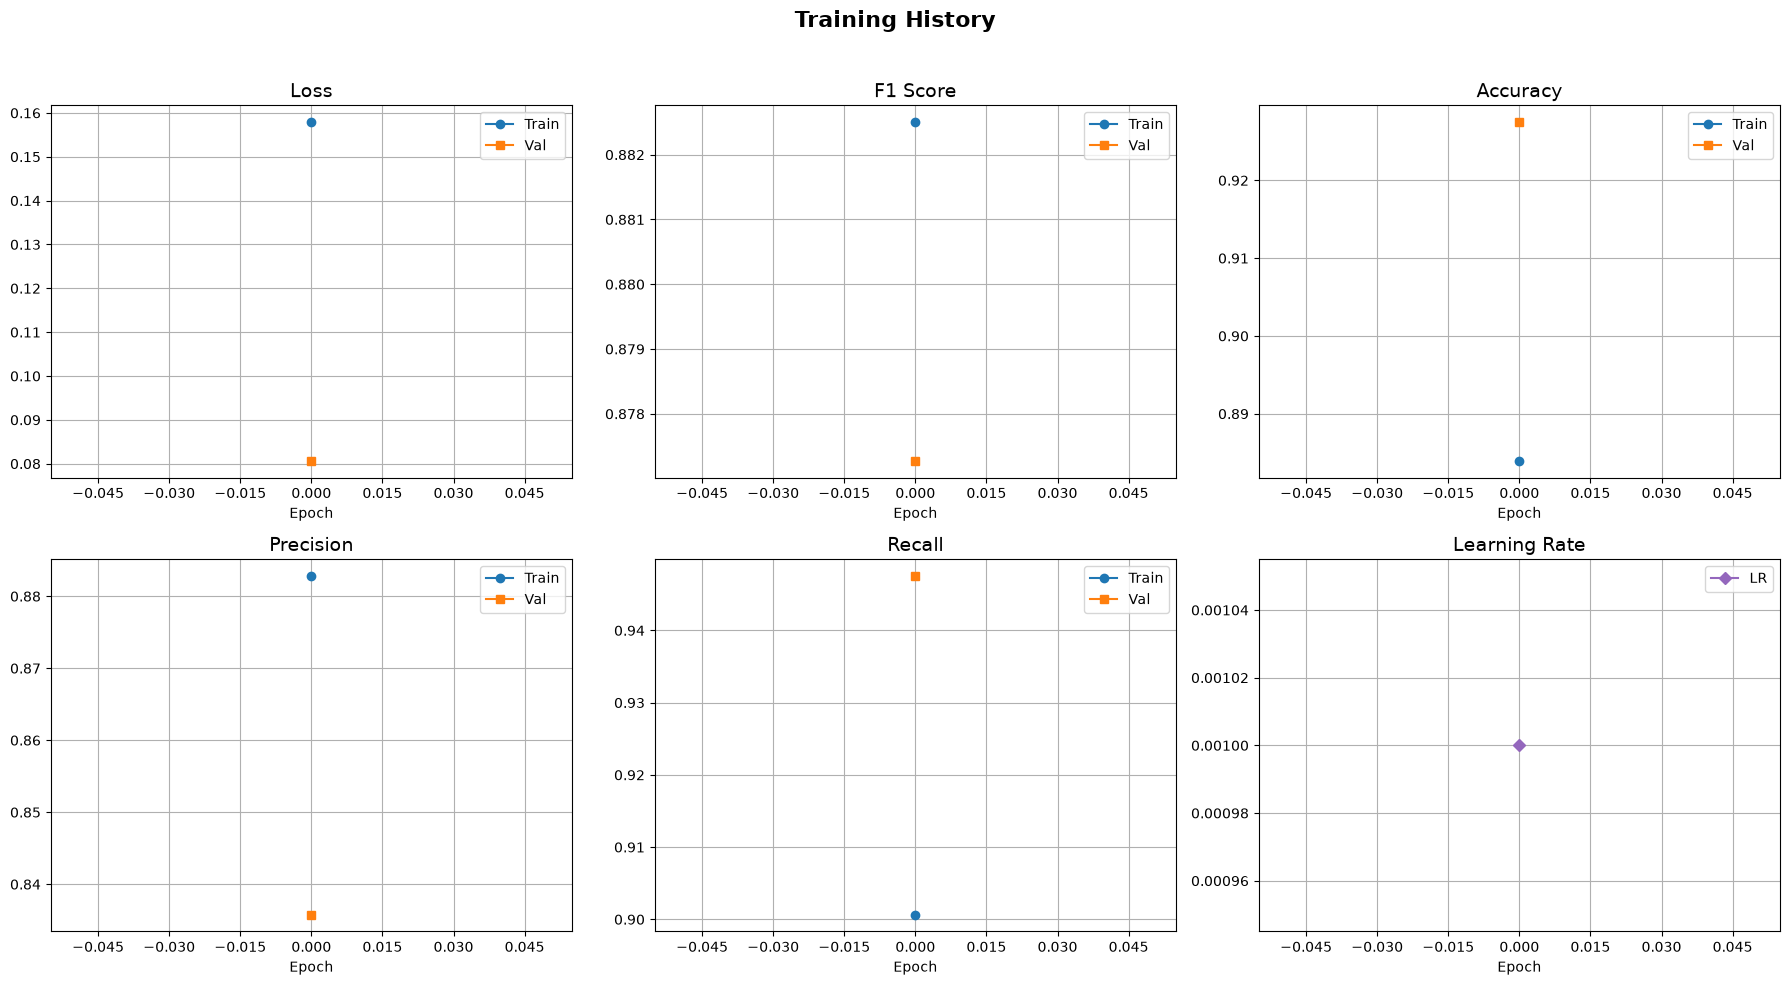

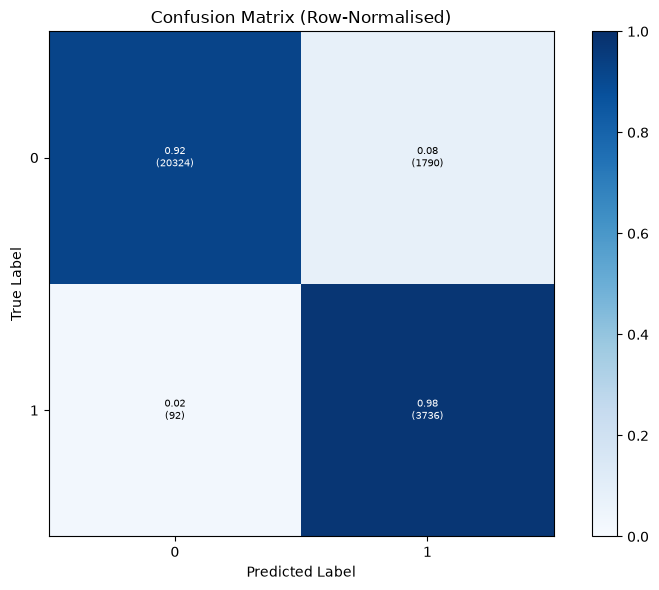


--- Stage 1 Best Val Per-Class F1 ---
+--------+------------+
|   none |   non-none |
+========+============+
| 0.9557 |     0.7988 |
+--------+------------+

val 的 none 被誤判成有缺陷：1790 / 22114（8.09%）
val 的缺陷樣本 Recall：0.9760


In [10]:
# Cell 7 — Stage 1：驗證集結果（test 留到 Cell 12 才動）
plot_history(history_s1, show=True)
plot_cm(best_cm_s1, num_classes_s1, show=True)
print("\n--- Stage 1 Best Val Per-Class F1 ---")
print_per_class_f1(best_f1pc_s1, class_names=["none", "non-none"])

# 假警報率：val 的 none 有多少被判成有缺陷（下一格就是要把這批挖出來）
fp = int(best_cm_s1[0, 1])
tn = int(best_cm_s1[0, 0])
print(f"\nval 的 none 被誤判成有缺陷：{fp} / {fp + tn}（{fp / max(fp + tn, 1):.2%}）")
print(f"val 的缺陷樣本 Recall：{best_cm_s1[1, 1] / max(best_cm_s1[1].sum(), 1):.4f}")

## Cell 8：困難樣本挖掘

Stage 1 訓練好之後，拿它去篩兩批 none，各挑出「真實是 none、但被判成有缺陷」的樣本：

- **B**（Stage 1 從頭到尾沒看過）→ 篩出來的當 **Stage 2 訓練集**的 none
- **val 的 none** → 篩出來的當 **Stage 2 驗證集**的 none

test 完全不碰。兩批各自篩、互不重疊，沒被篩出來的 none 之後都不使用。

In [ ]:
# Cell 8 — 困難樣本挖掘：用訓練好的 Stage 1 篩兩批 none
model_s1.load_state_dict(best_state_s1)
model_s1.eval()


def find_hard_none(none_df):
    """把一批 none 丟給 Stage 1，挑出「被誤判成有缺陷」的那些"""
    none_df = none_df.reset_index(drop=True)
    loader = DataLoader(
        WaferSimpleDataset(none_df, label_col="hasDefect", label_map=None, image_size=IMAGE_SIZE),
        batch_size=S1_BATCH_SIZE, shuffle=False, num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )

    flags = []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device, non_blocking=True)
            p_defect = torch.softmax(model_s1(images), dim=1)[:, 1]
            flags.append((p_defect > S1_THRESHOLD).cpu())
    flags = torch.cat(flags).numpy().astype(bool)

    return none_df[flags].reset_index(drop=True)


# B：Stage 1 完全沒看過 → 篩出來的當 Stage 2 訓練集的 none
hard_none_b = find_hard_none(none_b_df)
# val 的 none → 篩出來的當 Stage 2 驗證集的 none
hard_none_val = find_hard_none(val_none_df)

hard_none_b[["sample_id"]].to_csv(OUT_DIR / "hard_none_b.csv", index=False)
hard_none_val[["sample_id"]].to_csv(OUT_DIR / "hard_none_val.csv", index=False)

print(tabulate(
    [
        ["B（S1 沒看過）", len(none_b_df),   len(hard_none_b),   "→ S2 訓練集"],
        ["val none",       len(val_none_df), len(hard_none_val), "→ S2 驗證集"],
    ],
    headers=["來源", "總數", "被誤判成有缺陷", "去處"], tablefmt="grid",
))

## Stage 2：9 類分類（8 種缺陷 + none）

- **訓練** = train 的 8 類缺陷（含增強）+ B 篩出來的困難 none
- **驗證** = val 的 8 類缺陷 + val 的 none 篩出來的困難 none
- **測試** = test 整份，完全沒被動過

第 9 類直接沿用 `LABEL_MAP` 的 `none=8`，所以 Stage 2 的輸出索引就是最終的 9 類索引。

In [ ]:
# Cell 9 — Stage 2：組出 9 類的 train / val / test（含洩漏檢查）
s2_train_defect = train_defect_df.reset_index(drop=True)
if AUGMENT_S2:
    s2_train_defect = augment_selected_classes(s2_train_defect, classes=LOW_F1_CLASSES, random_seed=RANDOM_SEED)

# 訓練集 = train 的 8 類缺陷（含增強）+ B 篩出來的困難 none
s2_train = (
    pd.concat([s2_train_defect, hard_none_b], ignore_index=True)
    .sample(frac=1, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)
# 驗證集 = val 的 8 類缺陷 + val 的 none 篩出來的困難 none
s2_val  = pd.concat([val_defect_df, hard_none_val], ignore_index=True).reset_index(drop=True)
s2_test = test_df.reset_index(drop=True)

# ---- 洩漏檢查（用增強前的 sample_id 比對）--------------------------------
ids_s1_train = set(s1_train_df["sample_id"])
ids_hard_b   = set(hard_none_b["sample_id"])
ids_s2_train = set(train_defect_df["sample_id"]) | ids_hard_b
ids_s2_val   = set(s2_val["sample_id"])
ids_test     = set(s2_test["sample_id"])

assert not (ids_s2_train & ids_s2_val), "S2 訓練集和驗證集重疊"
assert not (ids_s2_train & ids_test),   "S2 訓練集和測試集重疊"
assert not (ids_s2_val   & ids_test),   "S2 驗證集和測試集重疊"
assert not (ids_s1_train & ids_hard_b), "B 被 Stage 1 訓練看過了"
assert not (ids_s1_train & ids_s2_val), "S2 驗證集的樣本被 Stage 1 訓練看過"

num_classes_s2 = len(LABEL_MAP)   # 9
datasets_s2 = {
    "train": WaferSimpleDataset(s2_train, label_map=LABEL_MAP, image_size=IMAGE_SIZE),
    "val":   WaferSimpleDataset(s2_val,   label_map=LABEL_MAP, image_size=IMAGE_SIZE),
}
dataloaders_s2 = make_dataloaders(datasets_s2, S2_BATCH_SIZE)

model_s2     = SimpleCNN(num_classes_s2).to(device)
criterion_s2 = nn.CrossEntropyLoss()
optimizer_s2 = AdamW(model_s2.parameters(), lr=S2_LR)
scheduler_s2 = ReduceLROnPlateau(optimizer_s2, mode="max", patience=2, factor=0.5)

print("洩漏檢查通過：S2 的 train / val / test 三份互不重疊")
if len(hard_none_b) == 0:
    print("[警告] Stage 1 沒有誤判 B 裡的任何 none，S2 訓練集裡沒有 none 樣本，"
          "串接後永遠不會把誤判修正回 none —— 請把 S1_THRESHOLD 再調低。")
if len(hard_none_val) == 0:
    print("[警告] Stage 1 沒有誤判 val 裡的任何 none，S2 驗證集裡沒有 none 樣本，"
          "none 這一類的驗證 F1 會是 0，checkpoint 會挑歪 —— 請把 S1_THRESHOLD 再調低。")
print(f"S2 訓練集：{len(s2_train)} 筆（缺陷 {len(s2_train_defect)}，B 篩出來的 none {len(hard_none_b)}，增強={AUGMENT_S2}）")
print(f"S2 驗證集：{len(s2_val)} 筆（缺陷 {len(val_defect_df)}，val 篩出來的 none {len(hard_none_val)}）")
print(f"S2 測試集：{len(s2_test)} 筆（最後端到端才會用到）")

In [13]:
# Cell 10 — Stage 2：訓練
print("===== Stage 2: 9-Class Classification (8 patterns + none) =====")
timer_s2 = EpochTimer()

best_state_s2, best_f1_s2, best_cm_s2, best_f1pc_s2, history_s2 = train_model(
    model_s2, device, criterion_s2, optimizer_s2, scheduler_s2, dataloaders_s2,
    learning_depend_metric="f1",
    num_classes=num_classes_s2,
    epochs=S2_EPOCHS,
    lr=S2_LR,
    epoch_callback=timer_s2,
    early_stopping=True, patience=S2_PATIENCE,
    class_names=list(LABEL_MAP.keys()),
)
time_per_epoch_s2 = timer_s2.get_time_per_epoch()
print(f"\nStage 2 完成，最佳驗證 F1：{best_f1_s2:.4f}")

===== Stage 2: 9-Class Classification (8 patterns + none) =====
===== Epoch 1/1 =====


KeyboardInterrupt: 

In [ ]:
# Cell 11 — Stage 2：驗證集結果（test 留到 Cell 12 才動）
plot_history(history_s2, show=True)
plot_cm(best_cm_s2, num_classes_s2, show=True)
print("\n--- Stage 2 Best Val Per-Class F1 ---")
print_per_class_f1(best_f1pc_s2, class_names=list(LABEL_MAP.keys()))

## Cell 12：端到端測試（唯一一次動 test）

流程：Stage 1 判 none 就直接輸出 none；判有缺陷才送進 Stage 2，由 Stage 2 在 9 類裡挑一個
（挑到 none 就等於把 Stage 1 的誤判修正回來）。最終輸出直接對真實 9 類標籤算分。

In [ ]:
# Cell 12 — 端到端測試：兩階段串起來，只跑這一次
model_s1.load_state_dict(best_state_s1)
model_s2.load_state_dict(best_state_s2)
model_s1.eval()
model_s2.eval()

NONE_IDX    = LABEL_MAP["none"]   # 8
test_loader = DataLoader(
    WaferSimpleDataset(s2_test, label_map=LABEL_MAP, image_size=IMAGE_SIZE),
    batch_size=S1_BATCH_SIZE, shuffle=False, num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

all_preds, all_labels, all_routed = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        # Stage 1：p(有缺陷) > 閾值才往下送，其餘直接輸出 none
        routed = torch.softmax(model_s1(images), dim=1)[:, 1] > S1_THRESHOLD
        final  = torch.full((images.size(0),), NONE_IDX, dtype=torch.long, device=images.device)

        # Stage 2：對被送進來的樣本做 9 類判斷（可能判回 none，修正 Stage 1 的誤判）
        if routed.any():
            final[routed] = model_s2(images[routed]).argmax(dim=1)

        all_preds.append(final.cpu())
        all_labels.append(labels)
        all_routed.append(routed.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
all_routed = torch.cat(all_routed).numpy()

unified_metrics = {
    "acc":          accuracy_score(all_labels, all_preds),
    "precision":    precision_score(all_labels, all_preds, average="macro", zero_division=0),
    "recall":       recall_score(all_labels, all_preds, average="macro", zero_division=0),
    "f1":           f1_score(all_labels, all_preds, average="macro", zero_division=0),
    "per_class_f1": f1_score(all_labels, all_preds, average=None, zero_division=0),
    "cm":           confusion_matrix(all_labels, all_preds, labels=list(range(num_classes_s2))),
}

n_routed  = int(all_routed.sum())
n_rescued = int(((all_preds == NONE_IDX) & all_routed).sum())
true_none = all_labels == NONE_IDX
print(f"測試集 {len(all_labels)} 筆")
print(f"  Stage 1 判有缺陷、送進 Stage 2：{n_routed}（其中真實是 none：{int((all_routed & true_none).sum())}）")
print(f"  Stage 2 判回 none（修正 Stage 1 誤判）：{n_rescued}")

In [ ]:
# Cell 12b — 最終 9 類分數
NINE_CLASS_NAMES = list(LABEL_MAP.keys())

print("=" * 60)
print(f"兩階段 Cascade — 統一 9 類別測試結果（S1 threshold={S1_THRESHOLD}）")
print(tabulate(
    [[f"{unified_metrics['f1']:.4f}", f"{unified_metrics['acc']:.4f}",
      f"{unified_metrics['precision']:.4f}", f"{unified_metrics['recall']:.4f}"]],
    headers=["F1", "Acc", "Precision", "Recall"],
    tablefmt="grid",
))
print_per_class_f1(unified_metrics["per_class_f1"], class_names=NINE_CLASS_NAMES)
plot_cm(unified_metrics["cm"], num_classes_s2, show=True)

In [ ]:
# Cell 13 — 單筆推論時間（兩階段串接）
import time

from explain.core import preprocess_wafer_simple


@torch.no_grad()
def cascade_predict(tensor):
    routed = torch.softmax(model_s1(tensor), dim=1)[:, 1] > S1_THRESHOLD
    out    = torch.full((tensor.size(0),), NONE_IDX, dtype=torch.long, device=tensor.device)
    if routed.any():
        out[routed] = model_s2(tensor[routed]).argmax(dim=1)
    return out


sample_input = s2_test.iloc[0]
preprocessed_wafer, _ = preprocess_wafer_simple(sample_input["waferMap"], IMAGE_SIZE, device)

_ = cascade_predict(preprocessed_wafer)  # warmup
if device.type == "cuda":
    torch.cuda.synchronize()
elif device.type == "mps":
    torch.mps.synchronize()

N = 100
t0 = time.perf_counter()
for _ in range(N):
    _ = cascade_predict(preprocessed_wafer)
if device.type == "cuda":
    torch.cuda.synchronize()
elif device.type == "mps":
    torch.mps.synchronize()
t1 = time.perf_counter()

inference_time = (t1 - t0) / N * 1000  # ms per sample
print(f"單樣本推論時間（{N} 次平均）：{inference_time:.3f} ms")

In [ ]:
# Cell 14 — 儲存結果
out_dir_s1 = OUT_DIR / "stage1"
out_dir_s2 = OUT_DIR / "stage2"
out_dir_s1.mkdir(parents=True, exist_ok=True)
out_dir_s2.mkdir(parents=True, exist_ok=True)

# 每個階段只存自己的驗證結果；test 分數只有串接後的那一份，不分開算
save_results(
    out_dir_s1, model_s1, best_state_s1, best_f1_s1,
    test_f1=None, test_cm=None, test_f1_per_class=None,
    history=history_s1, num_classes=num_classes_s1, label_map=NONE_NONONE_LABEL_MAP,
    image_size=IMAGE_SIZE, train_time_per_epoch=time_per_epoch_s1,
    model_name="simple_cnn",
)
save_results(
    out_dir_s2, model_s2, best_state_s2, best_f1_s2,
    test_f1=None, test_cm=None, test_f1_per_class=None,
    history=history_s2, num_classes=num_classes_s2, label_map=LABEL_MAP,
    image_size=IMAGE_SIZE, train_time_per_epoch=time_per_epoch_s2,
    model_name="simple_cnn",
)

for out_dir, cm, n in [(out_dir_s1, best_cm_s1, num_classes_s1), (out_dir_s2, best_cm_s2, num_classes_s2)]:
    fig = plot_cm(cm, n)
    fig.savefig(out_dir / "val_confusion_matrix.png", dpi=150)
    plt.close(fig)

# 端到端（唯一的 test 分數）
fig = plot_cm(unified_metrics["cm"], num_classes_s2)
fig.savefig(OUT_DIR / "unified_confusion_matrix.png", dpi=150)
plt.close(fig)

summary = {
    "experiment_name": EXPERIMENT_NAME,
    "model_name": "simple_cnn",
    "random_seed": RANDOM_SEED,
    "image_size": list(IMAGE_SIZE),
    "s1_threshold": S1_THRESHOLD,
    "augment": {"stage1": AUGMENT_S1, "stage2": AUGMENT_S2, "classes": LOW_F1_CLASSES},
    "counts": {
        "s1_train": len(s1_train), "s1_val": len(s1_val),
        "none_a": len(none_a_df), "none_b": len(none_b_df), "val_none": len(val_none_df),
        "hard_none_b": len(hard_none_b), "hard_none_val": len(hard_none_val),
        "s2_train": len(s2_train), "s2_val": len(s2_val), "test": len(s2_test),
    },
    "best_val_f1": {"stage1": best_f1_s1, "stage2": best_f1_s2},
    "unified_test": {
        "f1": unified_metrics["f1"], "acc": unified_metrics["acc"],
        "precision": unified_metrics["precision"], "recall": unified_metrics["recall"],
        "per_class_f1": unified_metrics["per_class_f1"].tolist(),
        "class_names": NINE_CLASS_NAMES,
        "cm": unified_metrics["cm"].tolist(),
        "routed_to_stage2": n_routed,
        "rescued_to_none_by_stage2": n_rescued,
    },
    "inference_time_ms": inference_time,
    "train_time_per_epoch": {"stage1": time_per_epoch_s1, "stage2": time_per_epoch_s2},
}
with open(OUT_DIR / "unified_metrics.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

print(f"結果已儲存至：{OUT_DIR}")

### 舊版（EfficientNet 兩階段）訓練筆記

**two_stage_20260531_110545**

發現：
- Stage 2 從第 4 epoch 之後 loss 不再下降、f1 不再上升，但到了 epoch 22 才提早停止，是否耐心訂的太多。
- val loss 有過擬合情況。epoch 5 val loss: 0.27 -> 表現最好的 epoch 16 val loss: 0.37。

**two_stage_20260606_xxx**

改動：
- 訓練 patience=3

### 這版的改動（SimpleCNN + 困難負樣本挖掘）

- backbone 換成 SimpleCNN（1 通道輸入，`WaferSimpleDataset`），訓練集加上翻轉/旋轉增強。
- Stage 1 閾值 0.3 → 0.1，checkpoint 指標 recall → f1（且指標本身就是套閾值後算的）。
- Stage 2 從 8 類改成 9 類，訓練資料混入 Stage 1 誤判的 none。
- 切分改成先切一次 train/val/test 再共用，修掉舊版「兩個階段各自 `split_df`」造成的
  train/val 交叉污染。
- train 的 none 對半切成 A / B：A 給 Stage 1 訓練，B 不給 Stage 1 看。
  Stage 1 訓練完，B 和 val 的 none 各篩一次，B 篩出來的當 S2 訓練集的 none、
  val 篩出來的當 S2 驗證集的 none —— 兩邊都是「實際會被送進 Stage 2」的樣本，
  取代舊版「未經篩選的 hold-out 池直接當 S2 驗證 none」的做法。
- test 只在最後端到端跑一次，分數不再由兩關各自計算後平均。